### Exploratory Data Analysis (EDA)

This notebook explores the dataset using visualizations and statistical summaries to understand patterns in divorce behavior.

In [17]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles here:")
print(os.listdir())

Current working directory:
/Users/melisbozali/Desktop/dsa210-divorce-project

Files here:
['eda.ipynb', '.DS_Store', '.ipynb_checkpoints', 'data']


In [19]:
import pandas as pd

df = pd.read_csv("data/usa_00001.csv", nrows=200000)

df.head()

,YEAR,SAMPLE,SERIAL,CBSERIAL,HHWT,CLUSTER,STATEICP,STRATA,GQ,PERNUM,PERWT,SEX,AGE,MARST,EDUC,EDUCD,EMPSTAT,EMPSTATD,INCWAGE,POVERTY
0,2023,202301,1,2023010000113,6.0,2023000000011,41,280201,3,1,6.0,2,86,5,6,63,3,30,0,0
1,2023,202301,2,2023010000180,27.0,2023000000021,41,10001,3,1,27.0,1,60,6,6,63,3,30,0,0
2,2023,202301,3,2023010000181,47.0,2023000000031,41,40201,4,1,47.0,1,20,6,7,71,3,30,0,0
3,2023,202301,4,2023010000250,11.0,2023000000041,41,270201,3,1,11.0,2,13,6,2,26,0,0,999999,0
4,2023,202301,5,2023010000340,57.0,2023000000051,41,280201,4,1,57.0,1,18,6,6,65,3,30,2500,0


In [21]:
# MARST: marital status
# 1 = married, 2 = spouse absent, 3 = separated, 4 = divorced, 5 = widowed, 6 = never married

df['divorced'] = df['MARST'].isin([3,4]).astype(int)

df['divorced'].value_counts()


divorced
0    177195
1     22805
Name: count, dtype: int64

In [23]:
df = df[df['MARST'] != 6]

In [25]:
# yaş grupları
df['age_group'] = pd.cut(df['AGE'],
                        bins=[18,25,35,45,55,65,100],
                        labels=['18-25','26-35','36-45','46-55','56-65','65+'])

# genç evlenen
df['young'] = (df['AGE'] <= 25).astype(int)

# log income
import numpy as np
df['log_income'] = np.log1p(df['INCWAGE'])

<Axes: title={'center': 'Divorce Distribution'}, xlabel='divorced'>

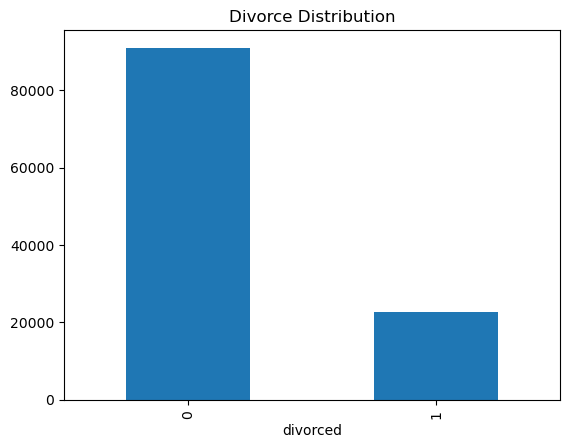

In [27]:
df['divorced'].value_counts().plot(kind='bar', title="Divorce Distribution")

<Axes: title={'center': 'Divorce by Age Group'}, xlabel='age_group'>

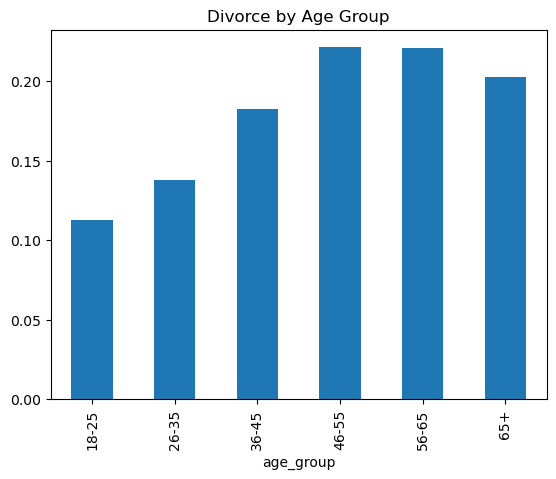

In [55]:
df.groupby('age_group', observed=False)['divorced'].mean().plot(
    kind='bar',
    title="Divorce by Age Group"
)

<Axes: title={'center': 'Divorce by Education'}, xlabel='EDUC'>

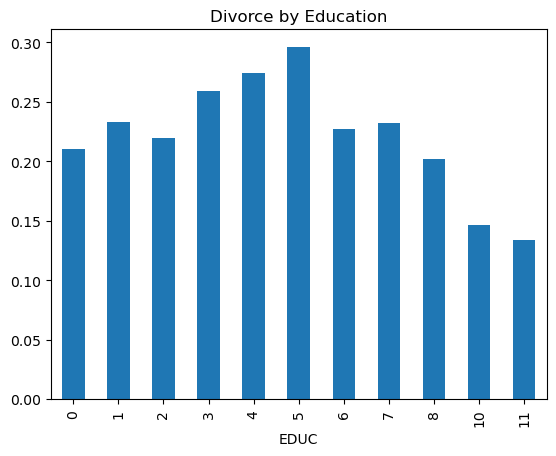

In [31]:
df.groupby('EDUC')['divorced'].mean().plot(kind='bar', title="Divorce by Education")

<Axes: title={'center': 'Divorce by Income'}, xlabel='INCWAGE'>

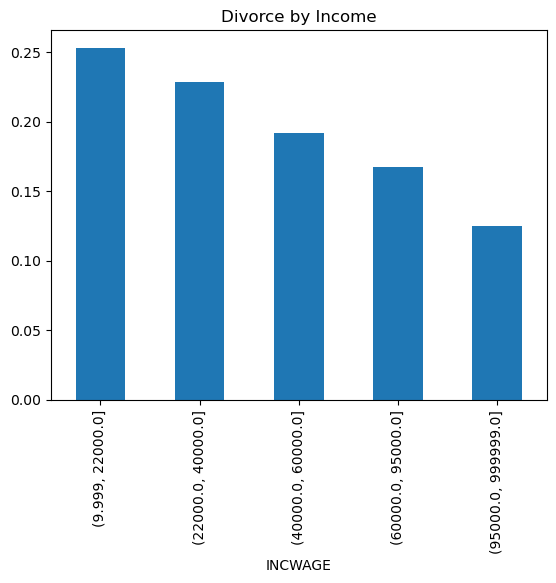

In [57]:
df = df[df['INCWAGE'] > 0]

df.groupby(
    pd.qcut(df['INCWAGE'], 5),
    observed=False
)['divorced'].mean().plot(
    kind='bar',
    title='Divorce by Income'
)

In [35]:
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu

In [37]:
div = df[df['divorced']==1]['AGE']
non = df[df['divorced']==0]['AGE']

ttest_ind(div, non)

TtestResult(statistic=-2.383616095678813, pvalue=0.0171451056590871, df=113811.0)

In [39]:
import pandas as pd

cont = pd.crosstab(df['EDUC'], df['divorced'])
chi2_contingency(cont)

Chi2ContingencyResult(statistic=1286.7804304144213, pvalue=2.7262810222535662e-270, dof=10, expected_freq=array([[ 1614.44783988,   404.55216012],
       [  360.63198404,    90.36801596],
       [ 1902.31372515,   476.68627485],
       [ 1113.08142304,   278.91857696],
       [ 1320.9845624 ,   331.0154376 ],
       [ 1585.66125135,   397.33874865],
       [33497.99351568,  8394.00648432],
       [13042.72348501,  3268.27651499],
       [ 8081.8347289 ,  2025.1652711 ],
       [16906.52336728,  4236.47663272],
       [11581.80411728,  2902.19588272]]))

In [41]:
div = df[df['divorced']==1]['INCWAGE']
non = df[df['divorced']==0]['INCWAGE']

mannwhitneyu(div, non)

MannwhitneyuResult(statistic=976380657.0, pvalue=5.287932470156822e-50)

In [43]:
cont = pd.crosstab(df['young'], df['divorced'])
chi2_contingency(cont)

Chi2ContingencyResult(statistic=111.09902700246191, pvalue=5.628762994411654e-26, dof=1, expected_freq=array([[89347.97339495, 22389.02660505],
       [ 1660.02660505,   415.97339495]]))

In [45]:
import pandas as pd
from scipy.stats import chi2_contingency

cont = pd.crosstab(df['young'], df['divorced'])
chi2_contingency(cont)

Chi2ContingencyResult(statistic=111.09902700246191, pvalue=5.628762994411654e-26, dof=1, expected_freq=array([[89347.97339495, 22389.02660505],
       [ 1660.02660505,   415.97339495]]))

In [47]:
df['divorced'] = df['MARST'].isin([3,4]).astype(int)
df = df[df['MARST'] != 6]
df['young'] = (df['AGE'] <= 25).astype(int) 
df.columns

Index(['YEAR', 'SAMPLE', 'SERIAL', 'CBSERIAL', 'HHWT', 'CLUSTER', 'STATEICP',
       'STRATA', 'GQ', 'PERNUM', 'PERWT', 'SEX', 'AGE', 'MARST', 'EDUC',
       'EDUCD', 'EMPSTAT', 'EMPSTATD', 'INCWAGE', 'POVERTY', 'divorced',
       'age_group', 'young', 'log_income'],
      dtype='object')

In [49]:
from scipy.stats import chi2_contingency
import pandas as pd

cont = pd.crosstab(df['young'], df['divorced'])
chi2_contingency(cont)

Chi2ContingencyResult(statistic=111.09902700246191, pvalue=5.628762994411654e-26, dof=1, expected_freq=array([[89347.97339495, 22389.02660505],
       [ 1660.02660505,   415.97339495]]))

In [ ]:
## Findings

This analysis examined the relationship between divorce status and socio-economic variables such as age, education, and income.

The results show that age is significantly associated with divorce status. The age-group visualization suggests that divorce rates increase from younger to middle-age groups and then decline slightly at older ages.

Education level also has a statistically significant relationship with divorce. Divorce rates vary across education categories, and higher education levels generally correspond to lower divorce rates.

Income is another important factor. Both the statistical test and the visualization suggest a negative relationship between income and divorce probability, with lower-income groups showing higher divorce rates.

Finally, the variable representing individuals aged 25 or younger also showed a significant association with divorce. This supports the idea that early-life conditions and younger age are related to marital instability.

Overall, the findings suggest that socio-economic conditions play an important role in divorce probability.